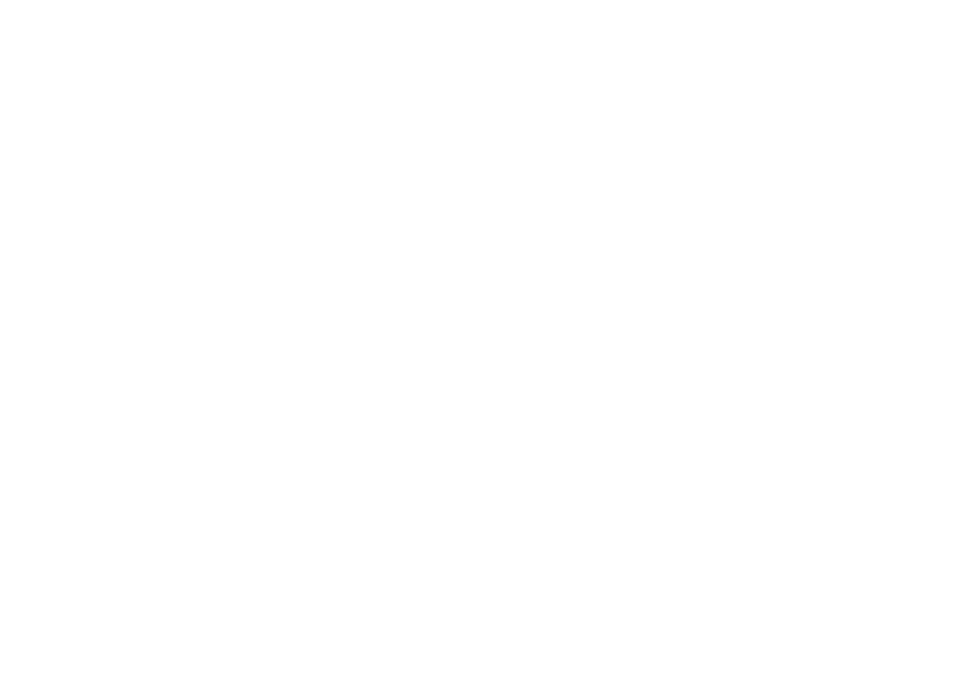

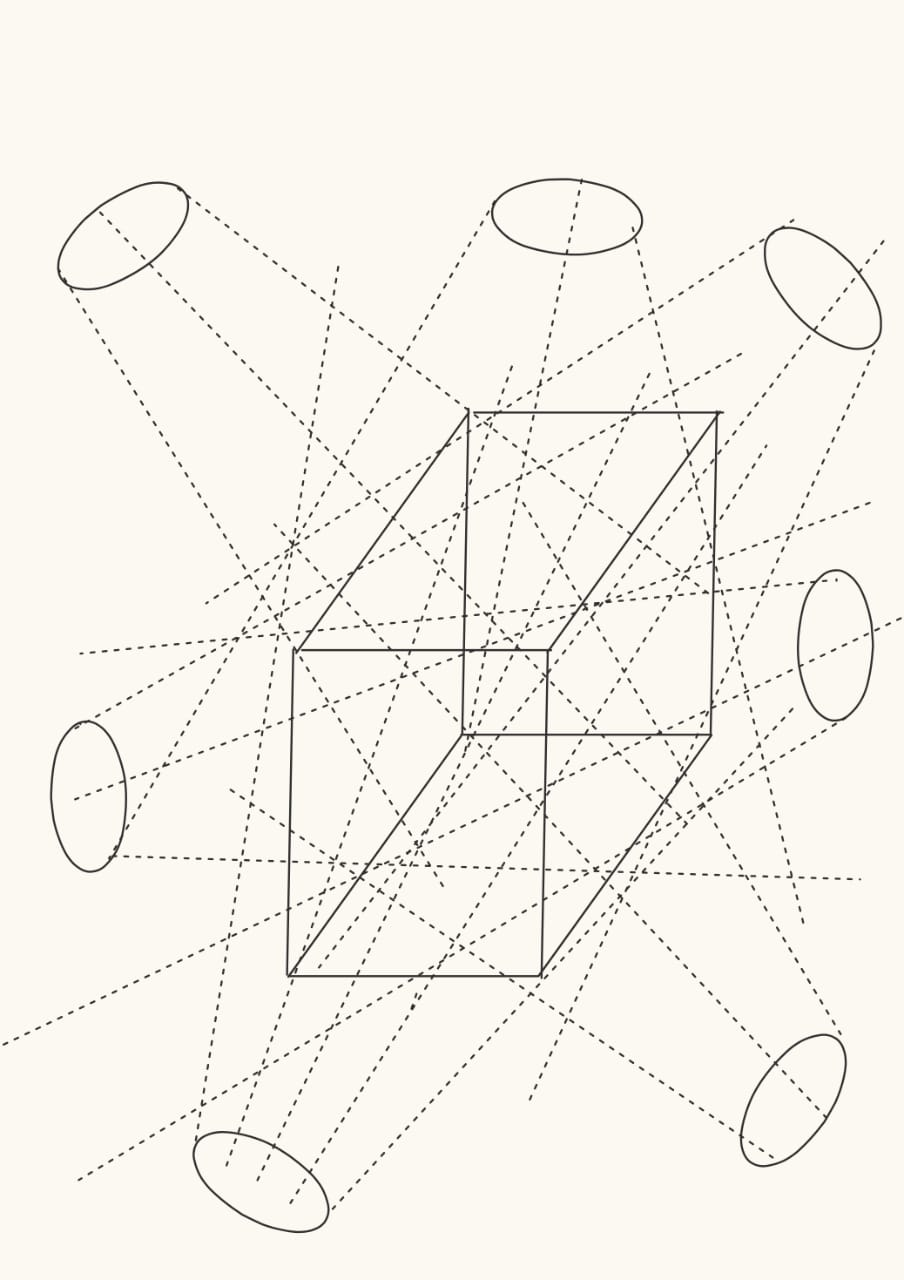

In [1]:
import torch
import numpy as np
from nerflab.camera.camera import Camera
from nerflab.camera.intrinsics import Intrinsics

def pose_translate(x=0, y=0, z=0, device="cpu", dtype=torch.float32):
    T = torch.eye(4, device=device, dtype=dtype)
    T[:3, 3] = torch.tensor([x, y, z], device=device, dtype=dtype)
    return T

def make_intr(W=32, H=24, fx=40.0, fy=40.0):
    return Intrinsics(fx=fx, fy=fy, width=W, height=H)


1) Unbatched: full grid, world vs camera frames, step & normalize

In [2]:
intr = make_intr(W=18, H=12, fx=20.0, fy=22.0)
H = pose_translate(z=1.0)
cam = Camera(H, intr=intr, t_bounds=(0.2, 2.0))

# World frame rays (origins at camera translation)
Ow, Dw = cam.get_rays(frame="world", step=2, normalize=True)
print("world:", Ow.shape, Dw.shape, Dw.norm(dim=-1).mean().item())

# Camera frame rays (origins at zero)
Oc, Dc = cam.get_rays(frame="camera", step=2, normalize=False)
print("camera:", Oc.shape, Dc.shape, Dc.norm(dim=-1).mean().item())

# Different step (denser grid)
O1, D1 = cam.get_rays(frame="world", step=1, normalize=True)
print("full-res:", O1.shape, D1.shape)


world: torch.Size([54, 3]) torch.Size([54, 3]) 1.0
camera: torch.Size([54, 3]) torch.Size([54, 3]) 1.0
full-res: torch.Size([216, 3]) torch.Size([216, 3])


2) Caching: instant re-use per (frame, step, normalize, device, dtype, pose_version)

In [3]:
# First call builds cache
cam.clear_cache()
Oa, Da = cam.get_rays(frame="world", step=2, normalize=True)
n1 = len(cam._rays_cache)

# Same args → cache hit (no new entry; identical tensor storage)
Ob, Db = cam.get_rays(frame="world", step=2, normalize=True)
n2 = len(cam._rays_cache)
print("cache sizes:", n1, n2, "same ptr:", Oa.data_ptr()==Ob.data_ptr(), Da.data_ptr()==Db.data_ptr())

# Different step adds another entry
_ = cam.get_rays(frame="world", step=4, normalize=True)
print("entries after step=4:", len(cam._rays_cache))


cache sizes: 1 1 same ptr: True True
entries after step=4: 2


3) get_rays_sampled: by count (uniform without replacement)

In [4]:
# Warm cache for step=2
O_all, D_all = cam.get_rays(step=2)
R = O_all.shape[0]
K = max(8, R//4)

Osub, Dsub = cam.get_rays_sampled(rays_per_pose=K, step=2)
print("subset shapes:", Osub.shape, Dsub.shape)  # (K,3)

# Request all → same shape as full grid
Oall2, Dall2 = cam.get_rays_sampled(rays_per_pose=R, step=2)
print("all shapes:", Oall2.shape, Dall2.shape)   # (R,3)


subset shapes: torch.Size([13, 3]) torch.Size([13, 3])
all shapes: torch.Size([54, 3]) torch.Size([54, 3])


4) get_rays_sampled: by explicit indices

In [5]:
# Single-pose explicit indices
idx = torch.tensor([0, 5, 10, 15, 20], dtype=torch.long)
Oidx, Didx = cam.get_rays_sampled(indices=idx, step=2)
print("indices subset:", Oidx.shape, Didx.shape)


indices subset: torch.Size([5, 3]) torch.Size([5, 3])


5) Batched poses: per-pose origins & per-pose sampled indices

In [6]:
H_batch = torch.stack([pose_translate(z=1.0), pose_translate(x=1.0, z=2.0)], dim=0)
camB = Camera(H_batch, intr=intr, t_bounds=(0.2, 2.0))

OB, DB = camB.get_rays(frame="world", step=2, normalize=True)
print("batched shapes:", OB.shape, DB.shape)  # (B,R,3)

# Check each batch’s mean origin equals its t_wc
t_wc = camB.H_wc[..., :3, 3]
print("means ~ t_wc:", torch.allclose(OB[0].mean(0), t_wc[0], atol=1e-6),
                      torch.allclose(OB[1].mean(0), t_wc[1], atol=1e-6))

# Per-batch explicit indices (K per batch)
B, R, _ = OB.shape
K = 10
idxB = torch.stack([
    torch.arange(K),
    torch.arange(5, 5+K)
], dim=0)  # (B,K)

Os, Ds = camB.get_rays_sampled(indices=idxB, step=2)
print("batched sampled:", Os.shape, Ds.shape)  # (B,K,3)


batched shapes: torch.Size([2, 54, 3]) torch.Size([2, 54, 3])
means ~ t_wc: True True
batched sampled: torch.Size([2, 10, 3]) torch.Size([2, 10, 3])


6) Sampling along rays (NeRF-style stratified)

In [7]:
# Unbatched
O, D = cam.get_rays(step=3)
t, delta, pts = cam.sample_along_rays(O, D, deterministic=True)
print("sample shapes (unbatched):", t.shape, delta.shape, pts.shape)

# Monotonic depths sanity
assert torch.all(t[:, 1:] - t[:, :-1] >= -1e-7)

# Batched
OB, DB = camB.get_rays_sampled(rays_per_pose=3, rng=torch.manual_seed(0))
tB, dB, pB = camB.sample_along_rays(OB, DB, deterministic=False)
print("sample shapes (batched):", tB.shape, dB.shape, pB.shape)
print(DB)

sample shapes (unbatched): torch.Size([24, 20]) torch.Size([24, 20]) torch.Size([24, 20, 3])
sample shapes (batched): torch.Size([2, 3, 20]) torch.Size([2, 3, 20]) torch.Size([2, 3, 20, 3])
tensor([[[ 0.0991,  0.0901, -0.9910],
         [-0.2423,  0.0441, -0.9692],
         [ 0.0991, -0.0901, -0.9910]],

        [[-0.2388,  0.1737, -0.9554],
         [-0.3701, -0.0841, -0.9252],
         [ 0.0971,  0.2206, -0.9705]]])


7) Device/dtype moves (cache invalidation + re-population)

In [8]:
if torch.cuda.is_available():
    cam_cuda = Camera(H, intr=intr, t_bounds=(0.2, 2.0)).to(torch.device("cuda"), torch.float32)
    Oc, Dc = cam_cuda.get_rays(frame="world", step=2, normalize=True)
    print("cuda:", Oc.is_cuda, Dc.is_cuda, len(cam_cuda._rays_cache))


cuda: True True 1


8) Pose updates (invalidate + reuse)

In [9]:
cam2 = Camera(H, intr=intr, t_bounds=(0.2, 2.0))
_ = cam2.get_rays(step=2)      # fills cache
print("cache before pose:", len(cam2._rays_cache))

cam2.set_poses(pose_translate(z=3.0))  # invalidates rays cache
print("cache after set_poses:", len(cam2._rays_cache))

_ = cam2.get_rays(step=2)      # rebuilds cache for new pose
print("cache after rebuild:", len(cam2._rays_cache))


cache before pose: 1
cache after set_poses: 0
cache after rebuild: 1


9) Quick cache timing (optional micro-benchmark)

In [10]:
import time

cam3 = Camera(H, intr=intr, t_bounds=(0.2, 2.0))
t0 = time.perf_counter()
_ = cam3.get_rays(step=1, normalize=True)   # cold
t1 = time.perf_counter()
_ = cam3.get_rays(step=1, normalize=True)   # warm hit
t2 = time.perf_counter()

print(f"cold: {(t1-t0)*1e3:.2f} ms | warm: {(t2-t1)*1e3:.2f} ms")


cold: 0.28 ms | warm: 0.03 ms


10) Plot helpers (if you wired them)

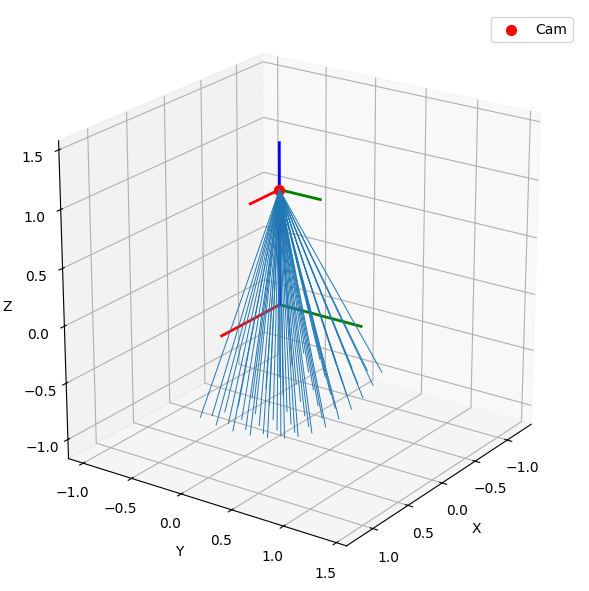

In [11]:
# Rays
cam.plot_rays(frame="world", step=2, mode="lines", color="C0", cam_index=0)


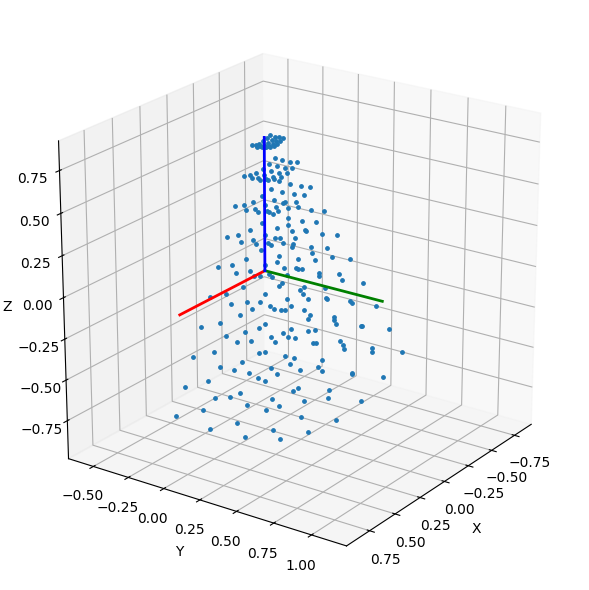

In [12]:
# Rays
cam.plot_rays(frame="world", step=2, mode="points", color="C0", cam_index=0, points=pts)


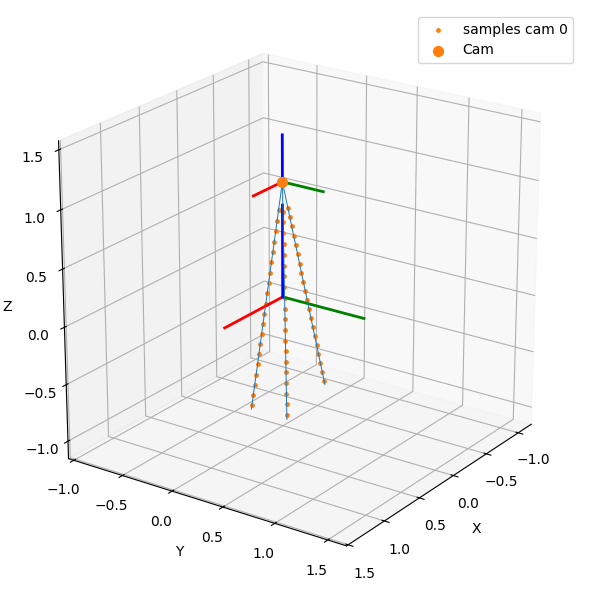

tensor([[ 0.0991,  0.0901, -0.9910],
        [-0.2423,  0.0441, -0.9692],
        [ 0.0991, -0.0901, -0.9910]])


In [13]:
camB.plot_samples(rays_per_pose=3, frame="world", show_rays=True, cam_index=0, deterministic=True, rng=torch.manual_seed(0))
print(DB[0])

In [14]:
# # test consistensiy torch.manual seed for get random samples rays
# pt1 = OB[0]
# pt2 = OB[0] + 3 * DB[0]
# import matplotlib.pyplot as plt
# # Plot
# fig = plt.figure()
# ax = fig.add_subplot(111, projection="3d")

# # Scatter start and end points
# ax.scatter(pt1[:,0], pt1[:,1], pt1[:,2], color="red", label="pt1 (origins)")
# ax.scatter(pt2[:,0], pt2[:,1], pt2[:,2], color="blue", label="pt2 (endpoints)")

# # Draw each line
# for i in range(pt1.shape[0]):
#     ax.plot([pt1[i,0], pt2[i,0]],
#             [pt1[i,1], pt2[i,1]],
#             [pt1[i,2], pt2[i,2]],
#             color="green")

# # Style
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")
# ax.legend()
# plt.show()


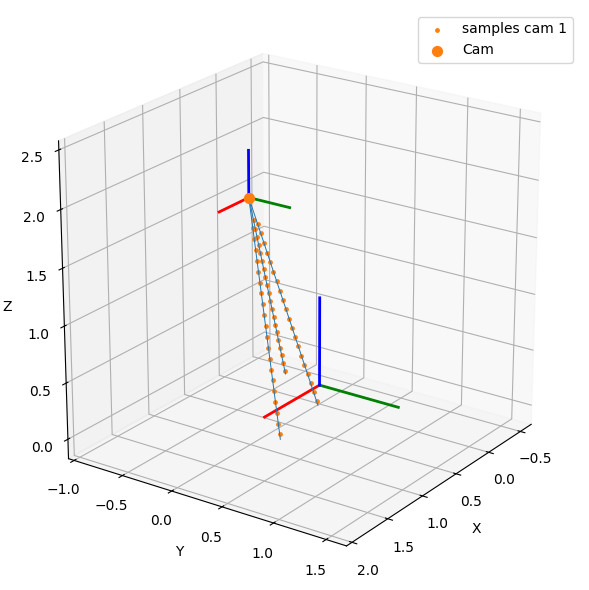

tensor([[-0.2388,  0.1737, -0.9554],
        [-0.3701, -0.0841, -0.9252],
        [ 0.0971,  0.2206, -0.9705]])


: 

In [ ]:
camB.plot_samples(rays_per_pose=3, frame="world", show_rays=True, cam_index=1, deterministic=True)
print(DB[1])